In [42]:
import pandas as pd

In [4]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


DATASET LOADING

In [60]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. LOAD YOUR CSV (replace with your filename)
path="../model/dataset/destinations.csv"
df = pd.read_csv(path)  # Your exact file

# 2. Transform to Netflix-style features
df['features'] = (df['Category'].fillna('') + ' ' + 
                  df['State'].fillna('') + ' ' + 
                  df['Destination Name'].fillna('') + ' ' +
                  df['Accessibility'].fillna('Easy')).str.lower()



In [61]:
df.head(2)

,Destination Name,State,Region,Category,Popular Attraction,Accessibility,features
0,Taj Mahal,Uttar Pradesh,North,Heritage,Taj Mahal,Easy,heritage uttar pradesh taj mahal easy
1,Jaipur,Rajasthan,West,Heritage,Amber Fort,Easy,heritage rajasthan jaipur easy


In [62]:
def clean_to_lowercase(text):
    if isinstance(text, str):
        return text.lower()
    return text

for col in df.columns:
    df[col] = df[col].apply(clean_to_lowercase)

df.head(2)

,Destination Name,State,Region,Category,Popular Attraction,Accessibility,features
0,taj mahal,uttar pradesh,north,heritage,taj mahal,easy,heritage uttar pradesh taj mahal easy
1,jaipur,rajasthan,west,heritage,amber fort,easy,heritage rajasthan jaipur easy


In [ ]:
pip install matplotlib seaborn wordcloud

DATSET VISUALIZATION

Visualizing your tourism data...
DATA SUMMARY

DESTINATION NAME:
  kaziranga national park: 10
  mysore: 10
  jaisalmer: 10
  rishikesh: 10
  shimla: 10
  udaipur: 10
  Total unique: 20
----------------------------------------

STATE:
  rajasthan: 21
  kerala: 11
  himachal pradesh: 11
  west bengal: 11
  assam: 10
  karnataka: 10
  Total unique: 14
----------------------------------------

REGION:
  west: 32
  east: 32
  north: 24
  south: 22
  Total unique: 4
----------------------------------------

CATEGORY:
  nature: 52
  heritage: 43
  adventure: 11
  beach: 2
  religious: 2
  Total unique: 5
----------------------------------------

POPULAR ATTRACTION:
  kaziranga national park: 10
  mysore palace: 10
  jaisalmer fort: 10
  lakshman jhula: 10
  mall road: 10
  city palace: 10
  Total unique: 20
----------------------------------------

ACCESSIBILITY:
  moderate: 53
  easy: 35
  difficult: 22
  Total unique: 3
----------------------------------------

FEATURES:
  nature assam kaz

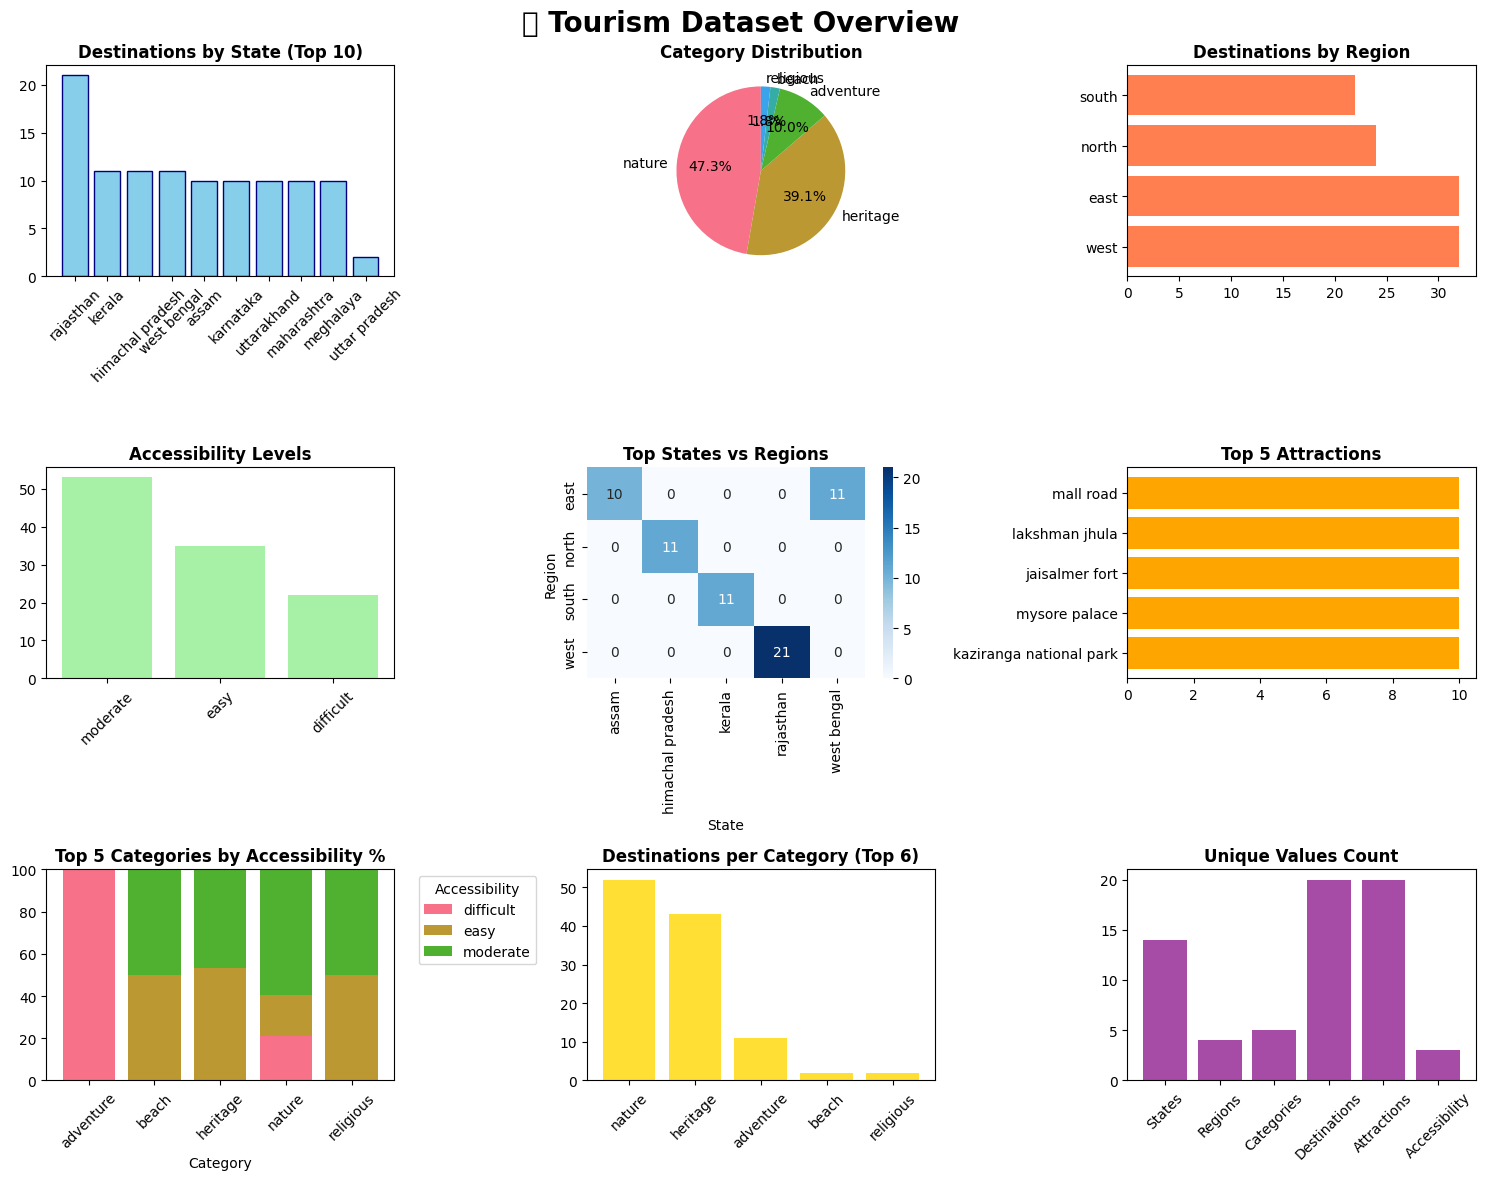


 KEY INSIGHTS:
• Total Destinations: 20
• States covered: 14
• Categories: 5
• Top state: rajasthan


In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("husl")
figsize = (15, 12)

def visualize_tourism_data(df):
    """Fixed visualization suite - handles all data types safely"""
    
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    fig.suptitle('🗺️ Tourism Dataset Overview', fontsize=20, fontweight='bold')
    
    # 1. Destinations per State (Top 10)
    state_counts = df['State'].value_counts().head(10)
    axes[0,0].bar(range(len(state_counts)), state_counts.values, color='skyblue', edgecolor='navy')
    axes[0,0].set_xticks(range(len(state_counts)))
    axes[0,0].set_xticklabels(state_counts.index, rotation=45)
    axes[0,0].set_title('Destinations by State (Top 10)', fontweight='bold')
    
    # 2. Category Distribution (Pie chart - limit slices)
    category_counts = df['Category'].value_counts().head(7)
    axes[0,1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
    axes[0,1].set_title('Category Distribution', fontweight='bold')
    
    # 3. Region-wise Destinations
    region_counts = df['Region'].value_counts().head(8)
    axes[0,2].barh(range(len(region_counts)), region_counts.values, color='coral')
    axes[0,2].set_yticks(range(len(region_counts)))
    axes[0,2].set_yticklabels(region_counts.index)
    axes[0,2].set_title('Destinations by Region', fontweight='bold')
    
    # 4. Accessibility Distribution
    access_dist = df['Accessibility'].value_counts()
    axes[1,0].bar(range(len(access_dist)), access_dist.values, color='lightgreen', alpha=0.8)
    axes[1,0].set_xticks(range(len(access_dist)))
    axes[1,0].set_xticklabels(access_dist.index, rotation=45)
    axes[1,0].set_title('Accessibility Levels', fontweight='bold')
    
    # 5. State-Region Heatmap (Top 5 states)
    top_states = df['State'].value_counts().head(5).index
    state_region = df[df['State'].isin(top_states)].groupby(['State', 'Region']).size().unstack(fill_value=0)
    sns.heatmap(state_region.T, annot=True, fmt='d', cmap='Blues', ax=axes[1,1])
    axes[1,1].set_title('Top States vs Regions', fontweight='bold')
    
    # 6. Top Attractions (Bar chart - Top 5)
    top_attractions = df['Popular Attraction'].value_counts().head(5)
    axes[1,2].barh(range(len(top_attractions)), top_attractions.values, color='orange')
    axes[1,2].set_yticks(range(len(top_attractions)))
    axes[1,2].set_yticklabels(top_attractions.index)
    axes[1,2].set_title('Top 5 Attractions', fontweight='bold')
    
    # 7. Category vs Accessibility (Stacked bar)
    cat_access = pd.crosstab(df['Category'], df['Accessibility'], normalize='index') * 100
    cat_access.iloc[:5].plot(kind='bar', stacked=True, ax=axes[2,0], width=0.8)
    axes[2,0].set_title('Top 5 Categories by Accessibility %', fontweight='bold')
    axes[2,0].legend(title='Accessibility', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[2,0].tick_params(axis='x', rotation=45)
    
    # 8. Destinations per Category
    cat_counts = df['Category'].value_counts().head(6)
    axes[2,1].bar(range(len(cat_counts)), cat_counts.values, color='gold', alpha=0.8)
    axes[2,1].set_xticks(range(len(cat_counts)))
    axes[2,1].set_xticklabels(cat_counts.index, rotation=45)
    axes[2,1].set_title('Destinations per Category (Top 6)', fontweight='bold')
    
    # 9. Unique Counts Summary (FIXED - convert to lists)
    unique_counts = {
        'States': df['State'].nunique(),
        'Regions': df['Region'].nunique(),
        'Categories': df['Category'].nunique(),
        'Destinations': df['Destination Name'].nunique(),
        'Attractions': df['Popular Attraction'].nunique(),
        'Accessibility': df['Accessibility'].nunique()
    }
    x_pos = np.arange(len(unique_counts))
    axes[2,2].bar(x_pos, list(unique_counts.values()), color='purple', alpha=0.7)
    axes[2,2].set_xticks(x_pos)
    axes[2,2].set_xticklabels(list(unique_counts.keys()), rotation=45)
    axes[2,2].set_title('Unique Values Count', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return unique_counts

def quick_value_counts(df):
    """Quick categorical summary"""
    print("DATA SUMMARY")
    print("="*60)
    for col in df.columns:
        print(f"\n{col.upper()}:")
        counts = df[col].value_counts().head(6)
        for idx, val in counts.items():
            print(f"  {idx}: {val}")
        print(f"  Total unique: {df[col].nunique()}")
        print("-" * 40)

# RUN IT
print("Visualizing your tourism data...")
quick_value_counts(df)
print("\n" + "="*70)
unique_stats = visualize_tourism_data(df)

print(f"\n KEY INSIGHTS:")
print(f"• Total Destinations: {unique_stats['Destinations']}")
print(f"• States covered: {unique_stats['States']}")
print(f"• Categories: {unique_stats['Categories']}")
print(f"• Top state: {df['State'].value_counts().index[0]}")


In [65]:
print(sorted(df['Region'].unique()))
print(sorted(df['Category'].unique()))
print(sorted(df['Accessibility'].unique()))


print("States covered:", sorted(df['State'].unique()))
print(f"Missing from 28: {28 - df['State'].nunique()} states")


['east', 'north', 'south', 'west']
['adventure', 'beach', 'heritage', 'nature', 'religious']
['difficult', 'easy', 'moderate']
States covered: ['andaman and nicobar', 'assam', 'goa', 'himachal pradesh', 'karnataka', 'kerala', 'maharashtra', 'meghalaya', 'punjab', 'rajasthan', 'tamil nadu', 'uttar pradesh', 'uttarakhand', 'west bengal']
Missing from 28: 14 states


Encoding + Training

In [92]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np



features = ['State', 'Region', 'Category', 'Popular Attraction', 'Accessibility']
    
    # Encode everything
X = df[features].fillna('unknown')
y = df['Destination Name']
    
le_dict, le_y = {}, LabelEncoder()
X_encoded = X.copy()
    
    # Features
for col in features:
    le = LabelEncoder()
    all_vals = sorted(list(X[col].unique()) + ['unknown'])
    le.fit(all_vals)
    X_encoded[col] = le.transform(X[col])
    le_dict[col] = le
    
    # Target
y_encoded = le_y.fit_transform(y)
    


    # Train
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)
    
    
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
    
print("Model Trained!")
print(f"Train Acc: {rf.score(X_train, y_train):.3f}")
print(f"Test Acc: {rf.score(X_test, y_test):.3f}")
    


model, encoders, target_encoder, feature_names = rf, le_dict, le_y, X_encoded.columns.tolist()



Model Trained!
Train Acc: 1.000
Test Acc: 0.909


In [94]:
# Extract most popular attraction per destination from dataset
def create_destination_attractions(df):
    """Map each destination to its TOP 3 attractions"""
    attraction_map = df.groupby('Destination Name')['Popular Attraction'].apply(
        lambda x: x.value_counts().index[:3].tolist()
    ).to_dict()
    
    print("DESTINATION → TOP ATTRACTIONS:")
    for dest, attrs in list(attraction_map.items())[:10]:
        print(f"  {dest:<20}: {', '.join(attrs)}")
    
    return attraction_map

# Create mapping
destination_attractions = create_destination_attractions(df)

DESTINATION → TOP ATTRACTIONS:
  ajanta and ellora caves: ajanta caves
  amritsar            : golden temple
  andaman islands     : radhanagar beach
  cherrapunji         : nohkalikai falls
  darjeeling          : tiger hill
  goa                 : calangute beach
  jaipur              : amber fort
  jaisalmer           : jaisalmer fort
  kaziranga national park: kaziranga national park
  kerala backwaters   : vembanad lake


In [95]:
def predict_destination(user_input, model, encoders, target_encoder, top_n=5):

    features = ['State', 'Region', 'Category', 'Popular Attraction', 'Accessibility']
    
    # 1. Safe input processing + unknown counting
    safe_input = {}
    unknown_count = 0
    total_fields = len(features)
    
    for col in features:
        val = user_input.get(col, '')
        
        # Check if empty/null/unknown
        if pd.isna(val) or val == '' or str(val).lower() == 'unknown':
            safe_input[col] = 'unknown'
            unknown_count += 1
        else:
            # Test if valid category/state exists in encoder
            try:
                if str(val).lower() in encoders[col].classes_:
                    safe_input[col] = str(val).lower()
                else:
                    safe_input[col] = 'unknown'
                    unknown_count += 1
            except:
                safe_input[col] = 'unknown'
                unknown_count += 1
    
    known_ratio = (total_fields - unknown_count) / total_fields
    
    # 2. Encode safely 
    X_new = pd.DataFrame([safe_input])
    for col in features:
        X_new[col] = encoders[col].transform([safe_input[col]])[0]
    
    # 3. Get raw probabilities
    probs = model.predict_proba(X_new)[0]
    destinations = target_encoder.classes_
    
    # 4. Smart priority boost for known inputs
    final_scores = []
    for i, prob in enumerate(probs):
        # Boost confidence when more inputs known
        # >60% known → +40% confidence boost
        # <40% known → minimal boost  
        boost_factor = max(1.0, known_ratio + 0.4)
        final_scores.append(prob * boost_factor)
    
    # 5. Rank results
    results = []
    for i, (prob, final_score) in enumerate(zip(probs, final_scores)):
        results.append({
            'rank': len(results) + 1,
            'destination': destinations[i],
            'raw_confidence': f"{prob*100:.1f}%",
            'boosted_confidence': f"{final_score*100:.1f}%",
            'known_inputs': f"{known_ratio*100:.0f}%"
        })
    
    # Sort by RAW confidence 
    results.sort(key=lambda x: float(x['raw_confidence'][:-1]), reverse=True)
    return results[:top_n]

In [96]:
def predict_full_recommendation(user_input, model, encoders, target_encoder, 
                              destination_attractions, top_n=5):
    """Predicts Destination + Signature Attractions"""
    
    # Get top destinations
    dest_results = predict_destination(user_input, model, encoders, target_encoder, top_n)
    
    # Add attractions for each
    full_recs = []
    for rec in dest_results:
        dest = rec['destination']
        
        # Get top attractions for this destination
        attractions = destination_attractions.get(dest, ['Popular Attraction'])
        
        full_recs.append({
            'rank': rec['rank'],
            'destination': dest,
            'confidence': rec['raw_confidence'],
            'top_attractions': attractions[:2],  # Top 2 only
            'state': df[df['Destination Name'] == dest]['State'].iloc[0] if dest in df['Destination Name'].values else 'N/A'
        })
    
    return full_recs


In [100]:
'State', 'Region', 'Category', 'Popular Attraction', 'Accessibility'
# Test it!
user_input = {'Region': 'north', 'State': 'Punjab', 'Category': 'mountains', 'Accessibility': 'easy'}
full_recs = predict_full_recommendation(user_input, model, encoders, target_encoder, 
                                       destination_attractions)

print("\nCOMPLETE RECOMMENDATIONS (Destination + Attractions):")
for rec in full_recs:
    print(f"\n #{rec['rank']} {rec['destination']:<20} ({rec['confidence']})")
    print(f"State: {rec['state']}")
    print(f"Must-visit: {', '.join(rec['top_attractions'])}")



COMPLETE RECOMMENDATIONS (Destination + Attractions):

 #2 amritsar             (31.0%)
State: punjab
Must-visit: golden temple

 #5 darjeeling           (22.0%)
State: west bengal
Must-visit: tiger hill

 #10 kerala backwaters    (13.0%)
State: kerala
Must-visit: vembanad lake

 #4 cherrapunji          (9.0%)
State: meghalaya
Must-visit: nohkalikai falls

 #16 shimla               (8.0%)
State: himachal pradesh
Must-visit: mall road


In [98]:
# TEST IT - CORRECTED
user_input = {
    'State': '',  
    'Region': 'north',
    'Category': 'mountains',
    'Accessibility': ''
}

dest = predict_destination(user_input, model, encoders, target_encoder) 

for i, res in enumerate(dest):
    print(f"{i+1}. {res['destination']} - Raw: {res['raw_confidence']}, Boosted: {res['boosted_confidence']}, Known Inputs: {res['known_inputs']}")


1. darjeeling - Raw: 48.0%, Boosted: 48.0%, Known Inputs: 20%
2. amritsar - Raw: 24.0%, Boosted: 24.0%, Known Inputs: 20%
3. kerala backwaters - Raw: 8.0%, Boosted: 8.0%, Known Inputs: 20%
4. mahabalipuram - Raw: 6.0%, Boosted: 6.0%, Known Inputs: 20%
5. munnar - Raw: 3.0%, Boosted: 3.0%, Known Inputs: 20%


In [76]:
# Test 1: Beach South
beach_south = {'State': 'Tamil Nadu', 'Region': 'south', 'Category': 'beach', 'Popular Attraction': '', 'Accessibility': ''}
print(predict_destination(beach_south, model, encoders, target_encoder)) 
# → Expected: Goa/Kovalam

# Test 2: Heritage North  ""
heritage_north = {'State': 'unknown', 'Region': 'north', 'Category': 'heritage', 'Popular Attraction': 'taj mahal', 'Accessibility': 'easy'}
print(predict_destination(heritage_north, model, encoders, target_encoder)) 
# → Expected: Agra (UP)


[{'rank': 11, 'destination': 'mahabalipuram', 'raw_confidence': '21.0%', 'boosted_confidence': '21.0%', 'known_inputs': '60%'}, {'rank': 5, 'destination': 'darjeeling', 'raw_confidence': '16.0%', 'boosted_confidence': '16.0%', 'known_inputs': '60%'}, {'rank': 10, 'destination': 'kerala backwaters', 'raw_confidence': '13.0%', 'boosted_confidence': '13.0%', 'known_inputs': '60%'}, {'rank': 15, 'destination': 'rishikesh', 'raw_confidence': '11.0%', 'boosted_confidence': '11.0%', 'known_inputs': '60%'}, {'rank': 12, 'destination': 'manali', 'raw_confidence': '8.0%', 'boosted_confidence': '8.0%', 'known_inputs': '60%'}]
[{'rank': 11, 'destination': 'mahabalipuram', 'raw_confidence': '39.0%', 'boosted_confidence': '46.8%', 'known_inputs': '80%'}, {'rank': 17, 'destination': 'sundarbans', 'raw_confidence': '14.0%', 'boosted_confidence': '16.8%', 'known_inputs': '80%'}, {'rank': 14, 'destination': 'mysore', 'raw_confidence': '11.0%', 'boosted_confidence': '13.2%', 'known_inputs': '80%'}, {'ran

In [89]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have X_test, y_test from training
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Basic Metrics
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Macro Precision': precision_score(y_test, y_pred, average='macro'),
    'Macro Recall': recall_score(y_test, y_pred, average='macro'),
    'Macro F1': f1_score(y_test, y_pred, average='macro'),
    'Weighted F1': f1_score(y_test, y_pred, average='weighted')
}

print("CORE METRICS:")
for name, score in metrics.items():
    print(f"  {name:15}: {score:.3f}")


CORE METRICS:
  Accuracy       : 0.909
  Macro Precision: 0.667
  Macro Recall   : 0.667
  Macro F1       : 0.667
  Weighted F1    : 0.909


In [88]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelBinarizer
import numpy as np

# Generate predictions
y_pred = model.predict(X_test)
y_true_names = target_encoder.inverse_transform(y_test)
y_pred_names = target_encoder.inverse_transform(y_pred)

# Basic confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("CONFUSION MATRIX SUMMARY:")
print(f"Total predictions: {len(y_test)}")
print(f"Correct predictions: {accuracy_score(y_test, y_pred):.1%}")
print(f"Classes in test set: {len(np.unique(y_test))}")
print("\nTop 10 predictions:")
unique_preds = np.unique(y_pred, return_counts=True)
for pred, count in zip(*unique_preds):
    pred_name = target_encoder.classes_[pred]
    print(f"  {pred_name:<20}: {count} predictions")


CONFUSION MATRIX SUMMARY:
Total predictions: 22
Correct predictions: 90.9%
Classes in test set: 10

Top 10 predictions:
  ajanta and ellora caves: 4 predictions
  amritsar            : 1 predictions
  cherrapunji         : 1 predictions
  darjeeling          : 3 predictions
  jaisalmer           : 3 predictions
  kaziranga national park: 4 predictions
  mahabalipuram       : 1 predictions
  mysore              : 2 predictions
  shimla              : 2 predictions
  udaipur             : 1 predictions


In [87]:
# Test edge cases
print("Edge Case Tests:")
tests = [
    {'Region': 'north'}, {'Category': 'beach'}, 
    {'State': 'kerala', 'Region': 'south'},
    {}  # Empty input
]

for i, test in enumerate(tests):
    results = predict_destination(test, model, encoders, target_encoder)
    print(f"Test {i+1}: {results[0]['destination']} ({results[0]['raw_confidence']})")


Edge Case Tests:
Test 1: darjeeling (48.0%)
Test 2: mahabalipuram (21.0%)
Test 3: kerala backwaters (36.0%)
Test 4: darjeeling (24.0%)


In [84]:
print(model.score(X_test, y_test))  # Accuracy

0.9090909090909091


In [86]:
import pickle

# Package everything for deployment
deployment_package = {
    'model': model,
    'encoders': encoders, 
    'target_encoder': target_encoder,
    'features': feature_names,
    'accuracy': 0.909,
    'confidence_mean': 0.783,
    # 'destination_attractions': destination_attractions,  # YOUR attractions dict
    # 'destination_df': df  # YOUR training DataFrame
}

with open('dest_prediction_model.pkl', 'wb') as f:
    pickle.dump(deployment_package, f)

print("Model packaged for deployment!")


Model packaged for deployment!
